In [1]:
import pandas as pd
import numpy as np

### Problem Statement

Tillu_mart is an online retail platform operating across multiple cities in Telangana. The company offers a wide range of daily essential products including groceries, dairy items, beverages, snacks, personal care products, and household items.

- The management team wants to analyze their annual sales data to understand:
    - Which products generate the highest revenue
    - Which cities contribute the most orders
    - How customers behave while purchasing online
    - Which categories have the highest demand
    - How delivery operations are performing
    - Whether discounts and coupons influence purchasing behavior
    - Which platform (Mobile App or Website) customers prefer

- The goal is to identify patterns, trends, and business opportunities that can help:
    - improve sales strategy
    - optimize product offerings
    - enhance customer experience
    - improve delivery efficiency
    - increase overall business profitability

In [2]:
df = pd.read_excel('tillu_mart_FINAL_clean_16000rows.xlsx')
df

,Order_ID,Order_Date,Year,Month,City,Latitude,Longitude,Customer_ID,Customer_Type,Product,...,Line_Total,Order_Total,Shipping_Cost,Payment_Mode,Order_Status,Delivery_Partner,Delivery_Time_min,Customer_Rating,Platform,Coupon_Code
0,ORD300000,2025-05-06,2025,5,Siddipet,18.1018,78.8520,CUST7338,New,Oil,...,269.13,988.76,0,Card,Delivered,Delhivery,56,4,Mobile App,NONE
1,ORD300000,2025-05-06,2025,5,Siddipet,18.1018,78.8520,CUST7338,New,Coffee,...,630.86,988.76,0,Card,Delivered,Delhivery,56,4,Mobile App,NONE
2,ORD300000,2025-05-06,2025,5,Siddipet,18.1018,78.8520,CUST7338,New,Butter,...,44.39,988.76,0,Card,Delivered,Delhivery,56,4,Mobile App,NONE
3,ORD300000,2025-05-06,2025,5,Siddipet,18.1018,78.8520,CUST7338,New,Atta,...,44.38,988.76,0,Card,Delivered,Delhivery,56,4,Mobile App,NONE
4,ORD300001,2025-08-23,2025,8,Siddipet,18.1018,78.8520,CUST5287,Regular,Shampoo,...,17.96,1656.49,0,UPI,Delivered,Swiggy Genie,51,3,Mobile App,NEW10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15537,ORD304497,2025-11-02,2025,11,Warangal,17.9689,79.5941,CUST6829,Regular,Oil,...,604.73,624.73,20,NetBanking,Delivered,Dunzo,58,5,Website,FESTIVE
15538,ORD304498,2025-12-06,2025,12,Warangal,17.9689,79.5941,CUST7233,Premium,Dal,...,197.03,858.79,30,NetBanking,Delivered,Swiggy Genie,44,4,Mobile App,NEW10
15539,ORD304498,2025-12-06,2025,12,Warangal,17.9689,79.5941,CUST7233,Premium,Tea,...,631.76,858.79,30,NetBanking,Delivered,Swiggy Genie,44,4,Mobile App,NEW10
15540,ORD304499,2025-08-23,2025,8,Warangal,17.9689,79.5941,CUST7590,Regular,Tea,...,673.65,722.63,0,Card,Delivered,Shadowfax,32,4,Mobile App,NONE


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15542 entries, 0 to 15541
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           15542 non-null  object 
 1   Order_Date         15542 non-null  object 
 2   Year               15542 non-null  int64  
 3   Month              15542 non-null  int64  
 4   City               15542 non-null  object 
 5   Latitude           15542 non-null  float64
 6   Longitude          15542 non-null  float64
 7   Customer_ID        15542 non-null  object 
 8   Customer_Type      15542 non-null  object 
 9   Product            15542 non-null  object 
 10  Category           15542 non-null  object 
 11  Quantity           15542 non-null  int64  
 12  Unit_Price         15542 non-null  float64
 13  Discount_%         15542 non-null  int64  
 14  Line_Total         15542 non-null  float64
 15  Order_Total        15542 non-null  float64
 16  Shipping_Cost      155

In [4]:
df.isnull().sum()

Order_ID             0
Order_Date           0
Year                 0
Month                0
City                 0
Latitude             0
Longitude            0
Customer_ID          0
Customer_Type        0
Product              0
Category             0
Quantity             0
Unit_Price           0
Discount_%           0
Line_Total           0
Order_Total          0
Shipping_Cost        0
Payment_Mode         0
Order_Status         0
Delivery_Partner     0
Delivery_Time_min    0
Customer_Rating      0
Platform             0
Coupon_Code          0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.shape

(15542, 24)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,15542.0,2025.000000,0.000000,2025.0000,2025.0000,2025.0000,2025.0000,2025.0000
Month,15542.0,6.520911,3.421984,1.0000,4.0000,7.0000,9.0000,12.0000
Latitude,15542.0,17.764041,0.590144,16.7375,17.3850,17.6244,18.1018,19.6725
Longitude,15542.0,78.747779,0.604625,77.9860,78.0941,78.4867,79.1288,80.1514
Quantity,15542.0,2.491185,1.121827,1.0000,1.0000,2.0000,3.0000,4.0000
Unit_Price,15542.0,86.445138,77.950052,3.0000,34.4500,55.7950,118.5950,419.7400
Discount_%,15542.0,10.145734,7.043920,0.0000,5.0000,10.0000,15.0000,20.0000
Line_Total,15542.0,193.994084,211.184984,2.4500,58.1775,124.2100,244.0225,1667.1200
Order_Total,15542.0,858.013957,530.024177,2.6300,456.2200,767.8800,1165.8700,3186.8300
Shipping_Cost,15542.0,22.039635,14.947614,0.0000,0.0000,20.0000,30.0000,40.0000


In [8]:
num_cols = df.select_dtypes(exclude='object').columns
num_cols

Index(['Year', 'Month', 'Latitude', 'Longitude', 'Quantity', 'Unit_Price',
       'Discount_%', 'Line_Total', 'Order_Total', 'Shipping_Cost',
       'Delivery_Time_min', 'Customer_Rating'],
      dtype='object')

In [9]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['Order_ID', 'Order_Date', 'City', 'Customer_ID', 'Customer_Type',
       'Product', 'Category', 'Payment_Mode', 'Order_Status',
       'Delivery_Partner', 'Platform', 'Coupon_Code'],
      dtype='object')

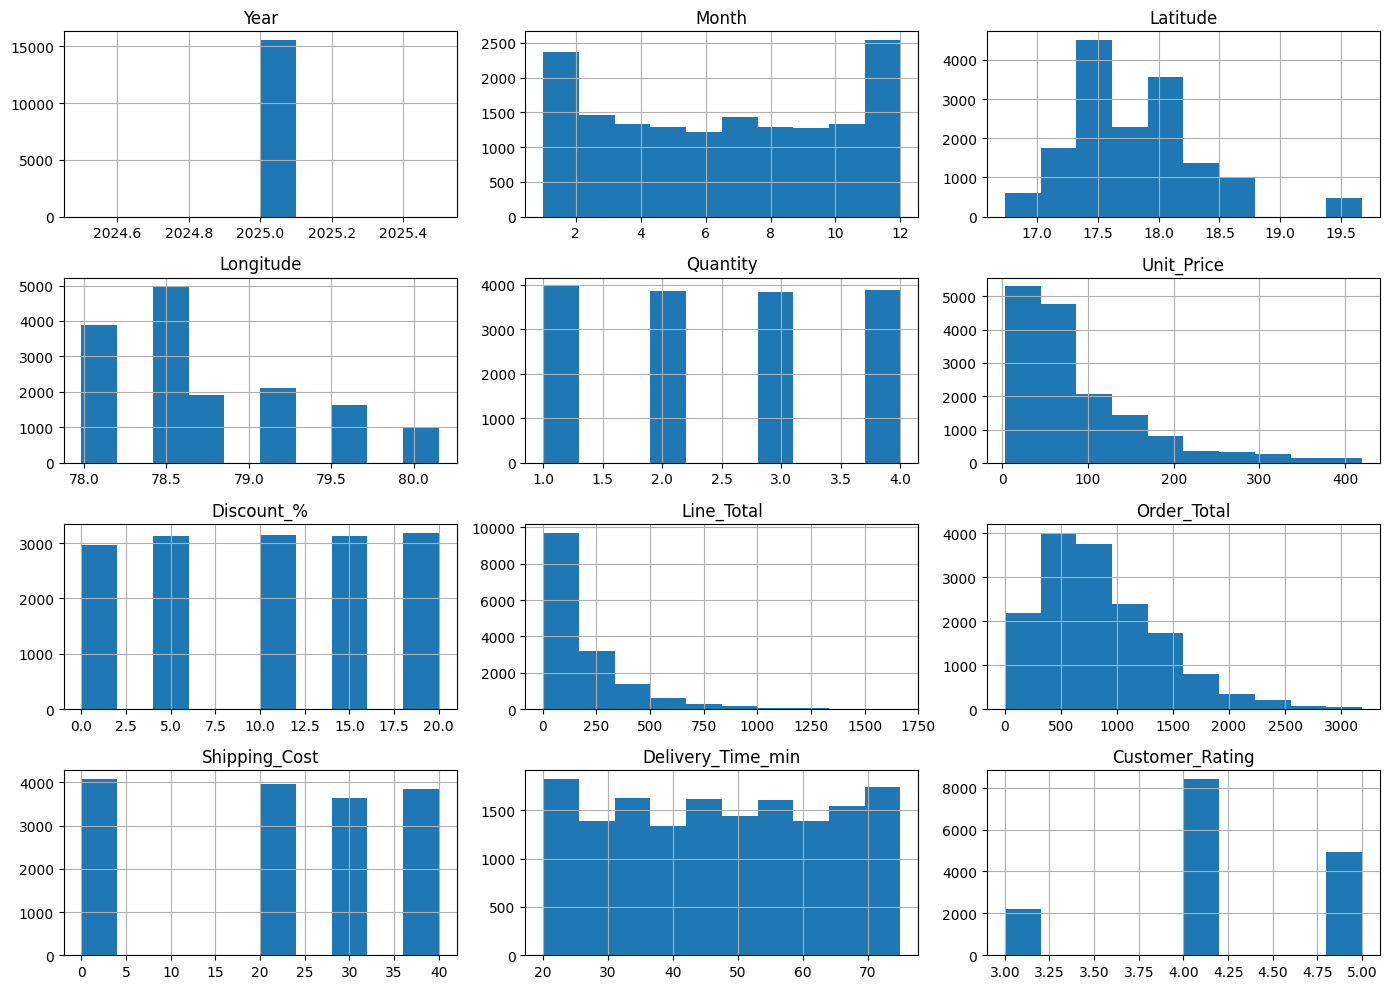

In [10]:
import matplotlib.pyplot as plt

df[num_cols].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

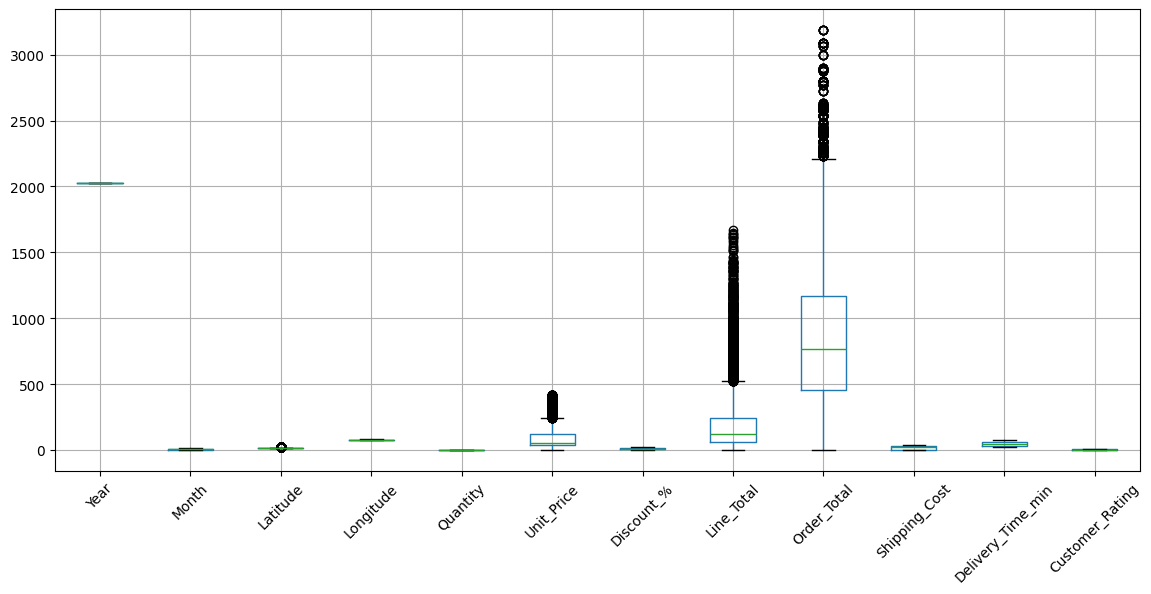

In [11]:
plt.figure(figsize=(14,6))
df[num_cols].boxplot(rot=45)
plt.show()

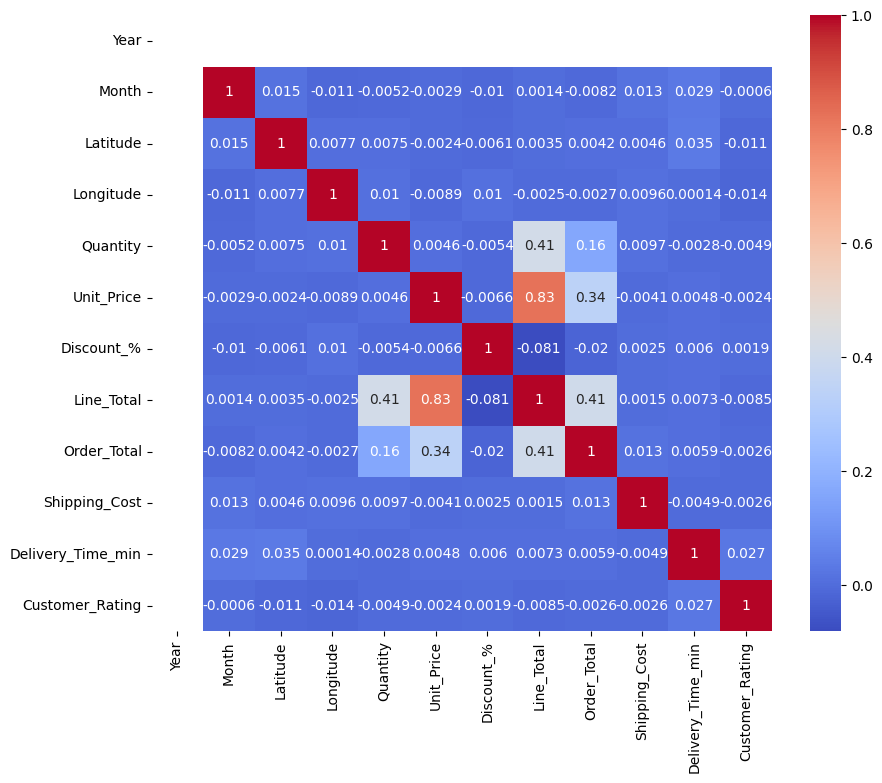

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [13]:
cat_cols

Index(['Order_ID', 'Order_Date', 'City', 'Customer_ID', 'Customer_Type',
       'Product', 'Category', 'Payment_Mode', 'Order_Status',
       'Delivery_Partner', 'Platform', 'Coupon_Code'],
      dtype='object')

In [14]:
cat_cols = [ 'City', 'Customer_Type','Product', 'Category', 'Payment_Mode', 'Order_Status','Delivery_Partner', 'Platform', 'Coupon_Code']

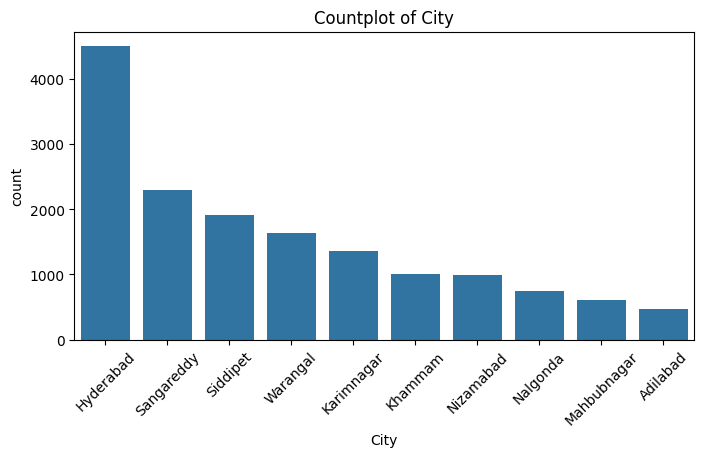

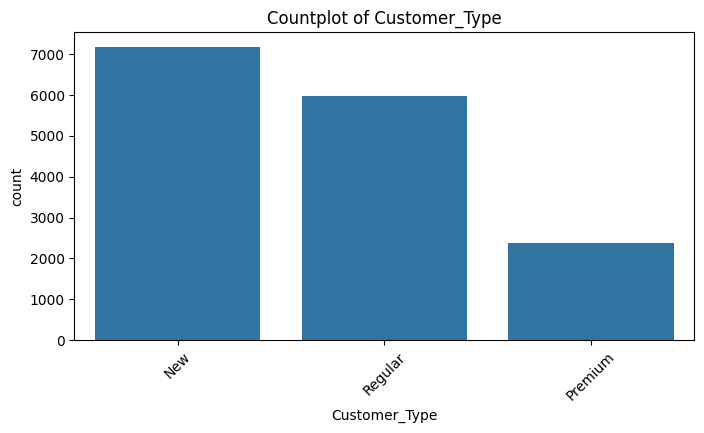

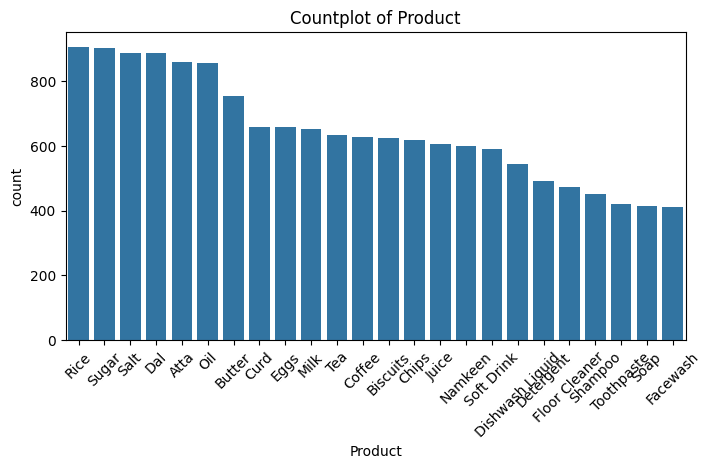

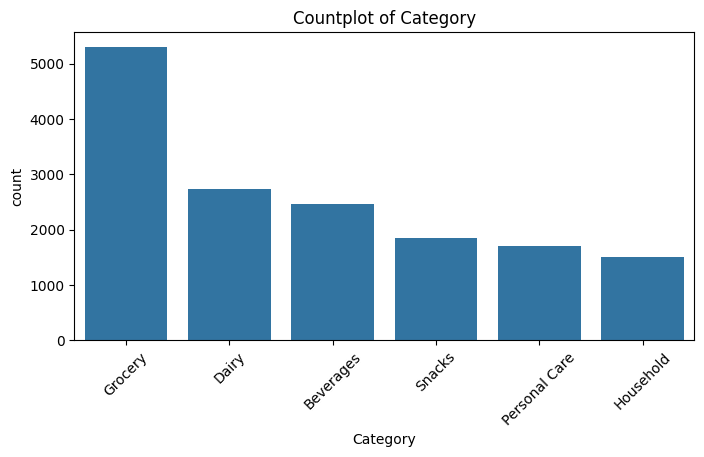

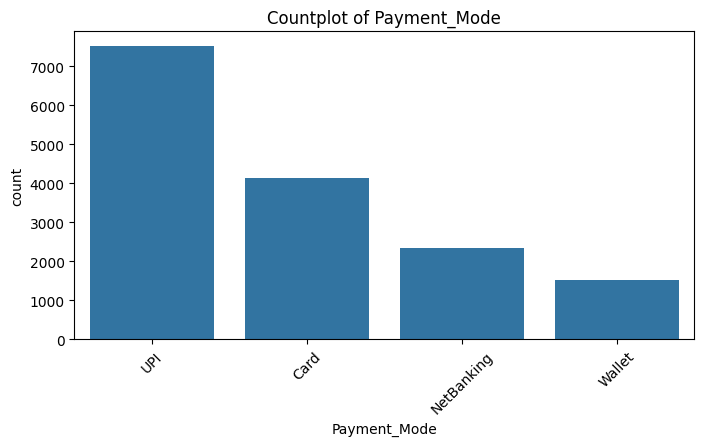

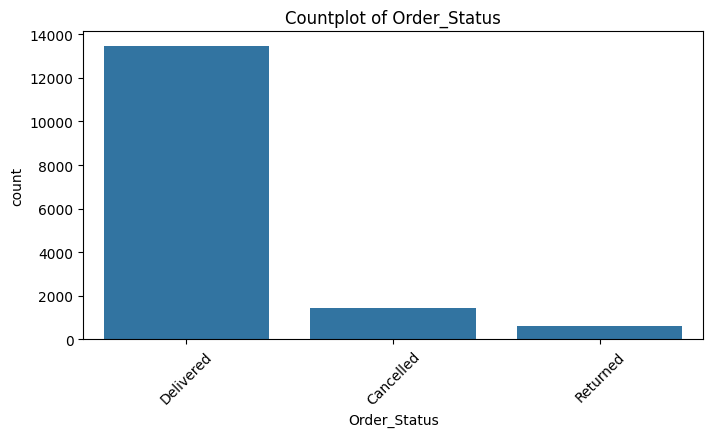

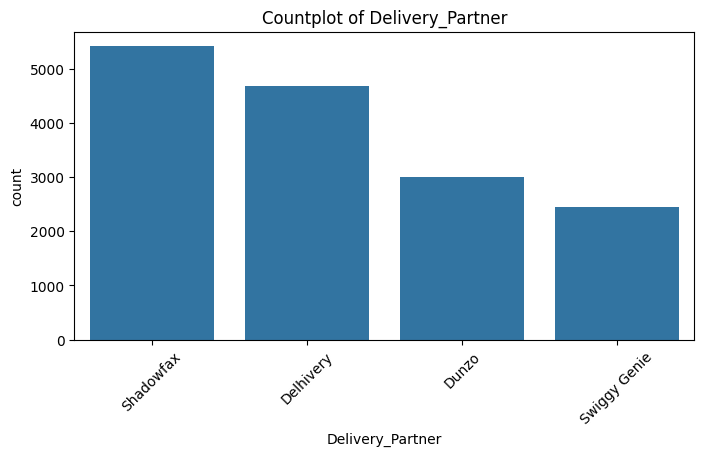

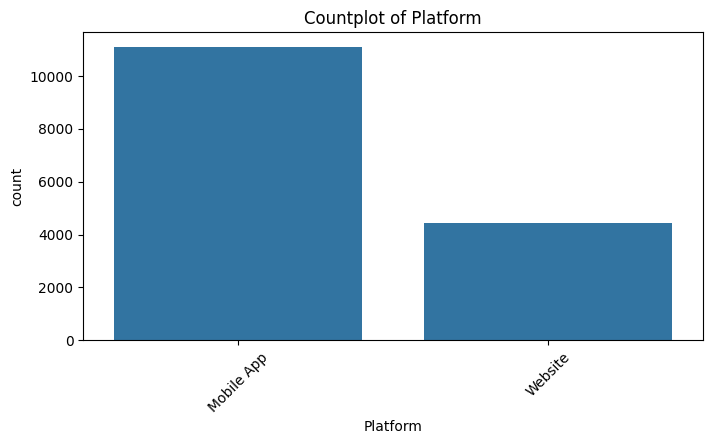

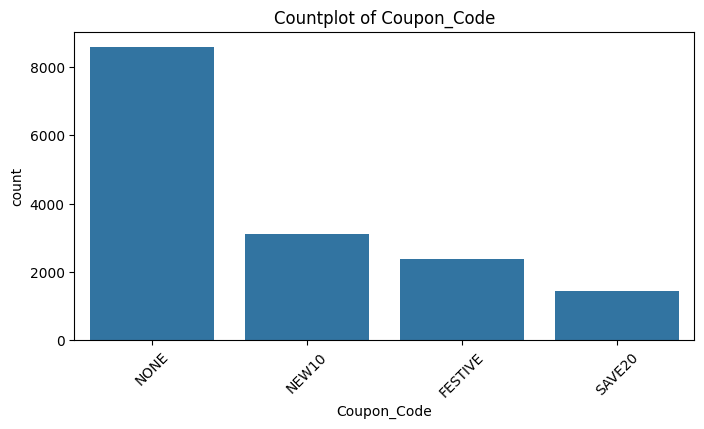

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

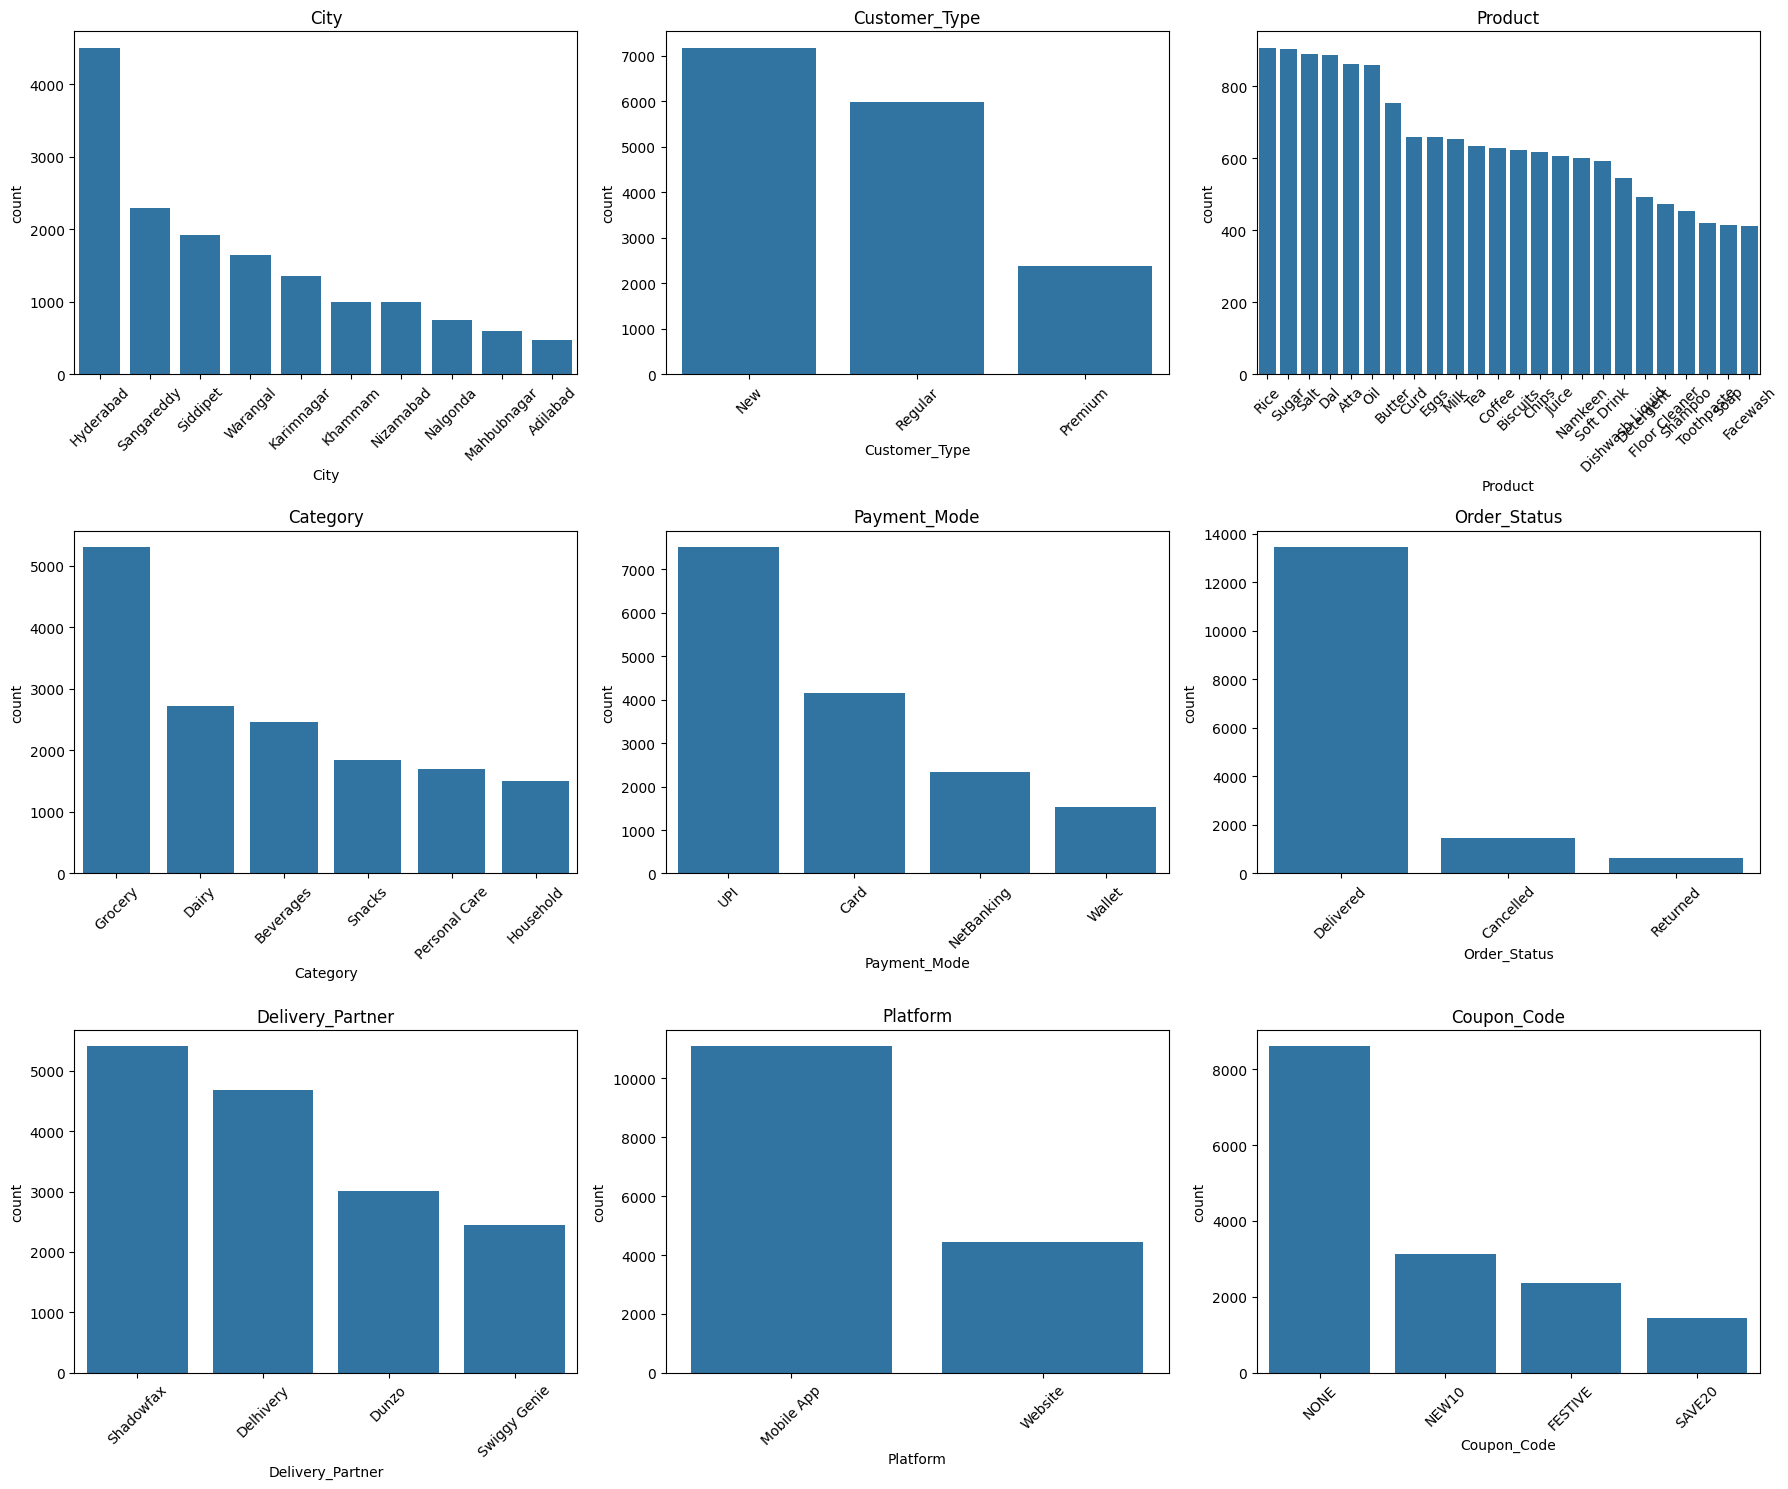

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 3
n_rows = math.ceil(len(cat_cols)/n_cols)

plt.figure(figsize=(18, 5*n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
df.sample(10)

,Order_ID,Order_Date,Year,Month,City,Latitude,Longitude,Customer_ID,Customer_Type,Product,...,Line_Total,Order_Total,Shipping_Cost,Payment_Mode,Order_Status,Delivery_Partner,Delivery_Time_min,Customer_Rating,Platform,Coupon_Code
10893,ORD303160,2025-06-13,2025,6,Nizamabad,18.6725,78.0941,CUST5590,New,Milk,...,109.22,741.37,0,UPI,Delivered,Shadowfax,71,5,Website,NONE
7933,ORD302310,2025-10-30,2025,10,Hyderabad,17.3850,78.4867,CUST6813,New,Atta,...,110.84,305.63,20,NetBanking,Delivered,Delhivery,59,5,Mobile App,NEW10
14448,ORD304187,2025-06-14,2025,6,Hyderabad,17.3850,78.4867,CUST2146,New,Atta,...,89.01,1737.97,40,NetBanking,Delivered,Delhivery,40,4,Mobile App,NONE
4397,ORD301271,2025-03-10,2025,3,Hyderabad,17.3850,78.4867,CUST5113,Regular,Coffee,...,375.93,1303.66,20,UPI,Delivered,Delhivery,26,5,Mobile App,NEW10
7035,ORD302046,2025-10-25,2025,10,Hyderabad,17.3850,78.4867,CUST6050,New,Namkeen,...,149.84,1618.02,30,Card,Delivered,Delhivery,72,5,Mobile App,NONE
5633,ORD301637,2025-05-31,2025,5,Hyderabad,17.3850,78.4867,CUST4884,New,Soap,...,75.47,449.62,20,UPI,Delivered,Delhivery,53,4,Mobile App,NONE
3607,ORD301038,2025-12-04,2025,12,Sangareddy,17.6244,78.0862,CUST3263,New,Atta,...,34.86,306.57,40,UPI,Delivered,Shadowfax,45,4,Mobile App,NONE
14481,ORD304196,2025-11-04,2025,11,Nizamabad,18.6725,78.0941,CUST7279,Premium,Rice,...,263.07,575.89,20,UPI,Delivered,Shadowfax,70,5,Mobile App,NEW10
8946,ORD302590,2025-10-19,2025,10,Hyderabad,17.3850,78.4867,CUST8978,New,Oil,...,286.58,386.22,40,UPI,Cancelled,Delhivery,46,3,Mobile App,NONE
4751,ORD301377,2025-04-01,2025,4,Khammam,17.2473,80.1514,CUST6850,New,Oil,...,217.79,1176.45,30,Card,Delivered,Dunzo,55,5,Mobile App,NONE
